In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier # O LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Fairness
from fairlearn.metrics import MetricFrame, selection_rate, demographic_parity_difference

# Explicabilidad
import shap

# Cross-validation
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score
from fairlearn.reductions import ExponentiatedGradient, DemographicParity

In [ ]:
def load_and_clean_compas(path):
    """
    Carga del dataset Compas, aplica los filtros metodológicos oficiales, 
    elimina NaNs y separa las variables predictivas (X) de la variable objetivo (y).
    """
    df = pd.read_csv(path)
    
    # 1. Filtrado por calidad de datos (Metodología ProPublica)
    df_clean = df[
        (df['days_b_screening_arrest'] <= 30) & 
        (df['days_b_screening_arrest'] >= -30) &
        (df['is_recid'] != -1) &
        (df['c_charge_degree'] != 'O') &
        (df['score_text'] != 'N/A')  # Añadido: excluir fallos del sistema original
    ].copy()
    
    # 2. Selección de variables relevantes (Features) y Target
    # Eliminamos 'age_cat' para evitar redundancia matemática con 'age'
    features = [
        'sex', 'age', 'race', 
        'juv_fel_count', 'juv_misd_count', 'juv_other_count', 
        'priors_count', 'c_charge_degree'
    ]
    target = 'two_year_recid'
    
    # 3. Nos quedamos solo con las columnas de interés y eliminamos NaNs residuales
    df_final = df_clean[features + [target]].dropna()
    
    # 4. Separación de X e y
    X = df_final[features].copy()
    y = df_final[target].copy()
    
    return X, y

#### **4.1 - Preprocesamiento**

In [17]:
X, y = load_and_clean_compas('./dataset/compas-scores-two-years.csv')

# Estrategia de estratificación (Target + Raza)
# Esto asegura que el sesgo racial se pueda medir con la misma precisión en train y test
stratify_cols = y.astype(str) + X['race'].astype(str)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30,        
    random_state=42, 
    stratify=stratify_cols # Estratificación multidimensional
)

# Identificación de tipos de columnas
numeric_features = ['age', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count']
categorical_features = ['sex', 'race', 'c_charge_degree']

# Creación de Transformers
# Para numéricas: Imputación por mediana + Escalado estándar
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Para categóricas: Imputación por el más frecuente + OneHot (evitando multicolinealidad)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Ensamblaje del ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

#### **4.2 - Modelo baseline**

##### Construcción del Pipeline

In [18]:
# 1. Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(n_estimators=100, random_state=42))
])

# 2. Entrenamiento
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

##### Rendimiento del modelo

In [19]:
def evaluar_rendimiento(pipeline, X_test, y_test):
    """Calcula las métricas de rendimiento estándar del modelo."""
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    }
    
    print("--- Rendimiento del Modelo ---")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")
    print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))
    
    return metrics

In [21]:
metricas = evaluar_rendimiento(pipeline, X_test, y_test)

--- Rendimiento del Modelo ---
Accuracy: 0.6555
AUC: 0.7014

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.66      0.75      0.70      1009
           1       0.64      0.55      0.59       843

    accuracy                           0.66      1852
   macro avg       0.65      0.65      0.65      1852
weighted avg       0.65      0.66      0.65      1852



##### Evaluación de Equidad (Fairness)

In [22]:
def evaluar_equidad(pipeline, X_test, y_test, grupo_sensible):
    """
    Evalúa si el modelo es 'justo' comparando predicciones entre grupos.
    grupo_sensible: Columna del dataset que representa la raza (atributo A).
    """
    y_pred = pipeline.predict(X_test)
    
    # Definimos las métricas a monitorizar por grupo
    metrics_dict = {
        'selection_rate': selection_rate, # Probabilidad de predecir reincidencia
        'accuracy': accuracy_score
    }
    
    mf = MetricFrame(
        metrics=metrics_dict,
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=grupo_sensible
    )
    
    dp_diff = demographic_parity_difference(y_test, y_pred, sensitive_features=grupo_sensible)
    
    print("--- Métricas de Equidad ---")
    print(f"Demographic Parity Difference: {dp_diff:.4f}")
    print("\nDesglose por grupo:\n", mf.by_group)
    
    return mf

In [23]:
grupo_sensible = X_test["race"]  # o la columna sensible que uses
mf = evaluar_equidad(pipeline, X_test, y_test, grupo_sensible)

--- Métricas de Equidad ---
Demographic Parity Difference: 0.4937

Desglose por grupo:
                   selection_rate  accuracy
race                                      
African-American        0.493697  0.651261
Asian                   0.222222  0.777778
Caucasian               0.256735  0.659271
Hispanic                0.398693  0.647059
Native American         0.000000  0.500000
Other                   0.233010  0.679612


##### Explicabilidad con SHAP

In [24]:
def explicar_modelo(pipeline, X_test):
    """Genera explicaciones post-hoc utilizando SHAP."""
    model = pipeline.named_steps['classifier']
    # Es necesario transformar los datos antes de pasarlos a SHAP
    X_transformed = pipeline.named_steps['preprocessor'].transform(X_test)
    
    # Nota: Si usas XGBoost o Random Forest, TreeExplainer es lo ideal
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_transformed)
    
    print("--- Generando Visualizaciones SHAP ---")
    # Resumen global de importancia de características
    shap.summary_plot(shap_values, X_transformed)

--- Generando Visualizaciones SHAP ---


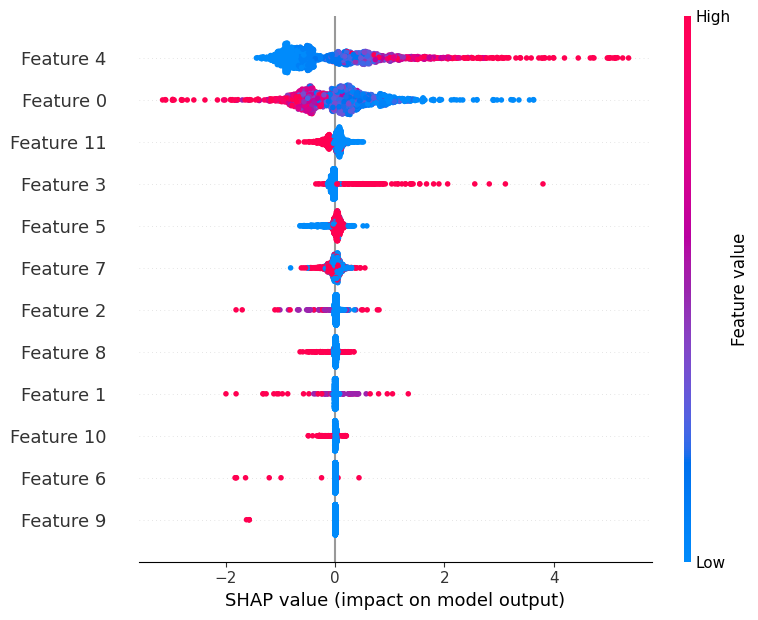

In [25]:
explicar_modelo(pipeline, X_test)

#### **4.3 - Tratamiento de la problemática 1: Fairness**

#### **5. Experimentos y Resultados**

In [30]:
# Definimos el Pipeline
pipeline_grid = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

# Parametros a explorar
param_grid = {
    'classifier__n_estimators': [25, 50, 75, 100],  
    'classifier__max_depth': [2, 3, 4],
    'classifier__learning_rate': [0.03, 0.05, 0.07, 0.1],
    'classifier__subsample': [0.2, 0.3, 0.4, 0.5],  
    'classifier__colsample_bytree': [0.5, 0.7, 1.0]
}

# Configuramos la Búsqueda
grid_search = GridSearchCV(
    estimator=pipeline_grid,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={
        'AUC': 'roc_auc', 
        'Accuracy': 'accuracy',
        'F1': 'f1',
        'Precision': 'precision',
        'Recall': 'recall'
    },
    refit='AUC', # La decisión final sobre quién es el ganador absoluto se toma por el AUC
    n_jobs=-1,
    verbose=1
)

print("Iniciando Grid Search...")

# Entrenamos
grid_search.fit(X_train, y_train)

print(f"Mejores Hiperparámetros:\n{grid_search.best_params_}")
print(f"AUC-ROC Máximo (Media CV): {grid_search.best_score_:.4f}")

# Guardamos el modelo ganador
mejor_pipeline_base = grid_search.best_estimator_

resultados_cv = grid_search.cv_results_

df_top_modelos = pd.DataFrame(resultados_cv['params'])
df_top_modelos.columns = [col.replace('classifier__', '') for col in df_top_modelos.columns]

# Añadimos las métricas de rendimiento
df_top_modelos['AUC-ROC'] = resultados_cv['mean_test_AUC']
df_top_modelos['Accuracy'] = resultados_cv['mean_test_Accuracy']
df_top_modelos['F1-Score'] = resultados_cv['mean_test_F1']
df_top_modelos['Precision'] = resultados_cv['mean_test_Precision']
df_top_modelos['Recall'] = resultados_cv['mean_test_Recall']

# Ordenamos de mayor a menor AUC y nos quedamos con los 10 primeros
df_top10 = df_top_modelos.sort_values(by='AUC-ROC', ascending=False).head(10).reset_index(drop=True)

print("\n--- TOP 10 MEJORES CONFIGURACIONES ---")
from IPython.display import display
display(df_top10)


Iniciando Grid Search...
Fitting 5 folds for each of 576 candidates, totalling 2880 fits
Mejores Hiperparámetros:
{'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.05, 'classifier__max_depth': 2, 'classifier__n_estimators': 75, 'classifier__subsample': 0.2}
AUC-ROC Máximo (Media CV): 0.7406

--- TOP 10 MEJORES CONFIGURACIONES ---


c:\Users\Usuario\Desktop\Clase\uni\AA\PF\AA_proyect\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:41:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,colsample_bytree,learning_rate,max_depth,n_estimators,subsample,AUC-ROC,Accuracy,F1-Score,Precision,Recall
0,1.0,0.05,2,75,0.2,0.740577,0.691204,0.641371,0.680657,0.606824
1,1.0,0.03,2,100,0.2,0.740423,0.693750,0.646443,0.681426,0.615473
2,1.0,0.05,2,100,0.2,0.740228,0.691667,0.644021,0.678787,0.612929
3,1.0,0.05,3,50,0.3,0.740222,0.694213,0.642296,0.687345,0.603267
4,1.0,0.05,3,50,0.2,0.740148,0.694444,0.642653,0.687210,0.603773
5,1.0,0.07,2,75,0.2,0.740045,0.694444,0.646402,0.683011,0.613951
6,1.0,0.03,3,75,0.2,0.740041,0.694676,0.643357,0.687587,0.605297
7,1.0,0.03,3,50,0.2,0.740020,0.692130,0.637221,0.687475,0.594109
8,1.0,0.07,2,75,0.3,0.739967,0.692361,0.643781,0.680897,0.610892
9,1.0,0.03,3,50,0.3,0.739958,0.691435,0.635771,0.687223,0.592078
